## Step 1: Tải dữ liệu phục vụ phân tích SQL

Trong bước này, hai tập dữ liệu đã được tạo ở giai đoạn tiền xử lý sẽ được nạp vào hệ thống.

- `online_retail_ii_basket_df.csv`: mỗi dòng đại diện cho một giỏ hàng (basket).
- `online_retail_ii_basket_items.csv`: mỗi dòng đại diện cho một sản phẩm trong giỏ hàng.

Hai tập dữ liệu này sẽ được sử dụng cho các phân tích SQL ở các bước tiếp theo.

In [ ]:
import pandas as pd
import sqlite3

# Đọc dữ liệu cấp giỏ hàng
basket_df = pd.read_csv("/content/online_retail_ii_basket_df.csv")

# Đọc dữ liệu cấp sản phẩm
basket_items = pd.read_csv("/content/online_retail_ii_basket_items.csv")

display(basket_df.head())
display(basket_items.head())

,InvoiceNo,Items,BasketSize,ProductRevenue,TotalQuantity,AvgUnitPrice,CustomerID,Country
0,489434,"['21232', '21523', '21871', '22041', '22064', ...",8,505.30,166,4.081250,13085.0,United Kingdom
1,489435,"['22195', '22349', '22350', '22353']",4,145.80,60,2.625000,13085.0,United Kingdom
2,489436,"['21181', '21333', '21754', '21755', '21756', ...",19,630.33,193,3.730526,13078.0,United Kingdom
3,489437,"['10002', '20695', '20703', '20971', '21351', ...",23,310.75,145,3.628261,15362.0,United Kingdom
4,489438,"['20711', '21033', '21100', '21252', '21329', ...",17,2286.24,826,2.591176,18102.0,United Kingdom


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,StockCodeLength,LineTotal
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,5,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,6,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,6,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,5,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,5,30.0


## Step 2: Tạo các bảng trong SQLite

Bước này tạo cơ sở dữ liệu SQLite từ hai tập dữ liệu đã nạp.

- Bảng `basket` lưu thông tin ở cấp độ giỏ hàng.
- Bảng `basket_items` lưu thông tin ở cấp độ sản phẩm.

Các bảng này sẽ được sử dụng để thực hiện các truy vấn SQL trong các bước phân tích tiếp theo.

In [ ]:
# Tạo kết nối SQLite
conn = sqlite3.connect("online_retail.db")

# Lưu dữ liệu cấp giỏ hàng vào SQL
basket_df.to_sql(
    "basket",
    conn,
    if_exists="replace",
    index=False
)

# Lưu dữ liệu cấp sản phẩm vào SQL
basket_items.to_sql(
    "basket_items",
    conn,
    if_exists="replace",
    index=False
)

print("Tables created successfully.")

Tables created successfully.


## Step 3: Phân tích đặc điểm giỏ hàng

Bước này tính toán các chỉ số cơ bản ở cấp độ giỏ hàng nhằm hiểu hành vi mua sắm của khách hàng.

Các chỉ số được phân tích gồm:

- Tổng số giỏ hàng (baskets)
- Kích thước giỏ hàng trung bình (average basket size)
- Số lượng sản phẩm trung bình trên mỗi hóa đơn
- Doanh thu trung bình trên mỗi hóa đơn
- Kích thước giỏ hàng nhỏ nhất và lớn nhất

In [ ]:
query = """
SELECT
    COUNT(*) AS total_baskets,
    ROUND(AVG(BasketSize), 2) AS avg_basket_size,
    ROUND(AVG(TotalQuantity), 2) AS avg_items_per_invoice,
    ROUND(AVG(ProductRevenue), 2) AS avg_revenue_per_invoice,
    MIN(BasketSize) AS min_basket_size,
    MAX(BasketSize) AS max_basket_size
FROM basket;
"""

# Thực thi câu lệnh SQL
basket_summary = pd.read_sql(query, conn)

# Hiển thị kết quả
basket_summary

,total_baskets,avg_basket_size,avg_items_per_invoice,avg_revenue_per_invoice,min_basket_size,max_basket_size
0,39516,25.11,283.13,497.11,1,1108


## Step 4: Phân tích 10 sản phẩm xuất hiện nhiều nhất

Bước này xác định các sản phẩm xuất hiện trong nhiều giỏ hàng nhất.

Kết quả giúp nhận diện các sản phẩm phổ biến nhất trong tập dữ liệu và cung cấp cơ sở cho việc phân tích luật kết hợp ở các bước tiếp theo.

In [ ]:
query = """
SELECT
    StockCode,
    Description,
    COUNT(DISTINCT InvoiceNo) AS basket_frequency
FROM basket_items
GROUP BY StockCode, Description
ORDER BY basket_frequency DESC
LIMIT 10;
"""

# Thực thi truy vấn SQL
top_products = pd.read_sql(query, conn)

# Hiển thị kết quả
top_products

,StockCode,Description,basket_frequency
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,5356
1,22423,REGENCY CAKESTAND 3 TIER,3918
2,85099B,JUMBO BAG RED RETROSPOT,3245
3,84879,ASSORTED COLOUR BIRD ORNAMENT,2807
4,47566,PARTY BUNTING,2674
5,20727,LUNCH BAG BLACK SKULL.,2351
6,21931,JUMBO STORAGE BAG SUKI,2329
7,21232,STRAWBERRY CERAMIC TRINKET BOX,2310
8,22411,JUMBO SHOPPER VINTAGE RED PAISLEY,2192
9,22469,HEART OF WICKER SMALL,2151


Biểu đồ cột được sử dụng để trực quan hóa 10 sản phẩm xuất hiện trong nhiều giỏ hàng nhất.

Sản phẩm có tần suất xuất hiện cao thường là các mặt hàng phổ biến và có tiềm năng tham gia vào nhiều luật kết hợp quan trọng.

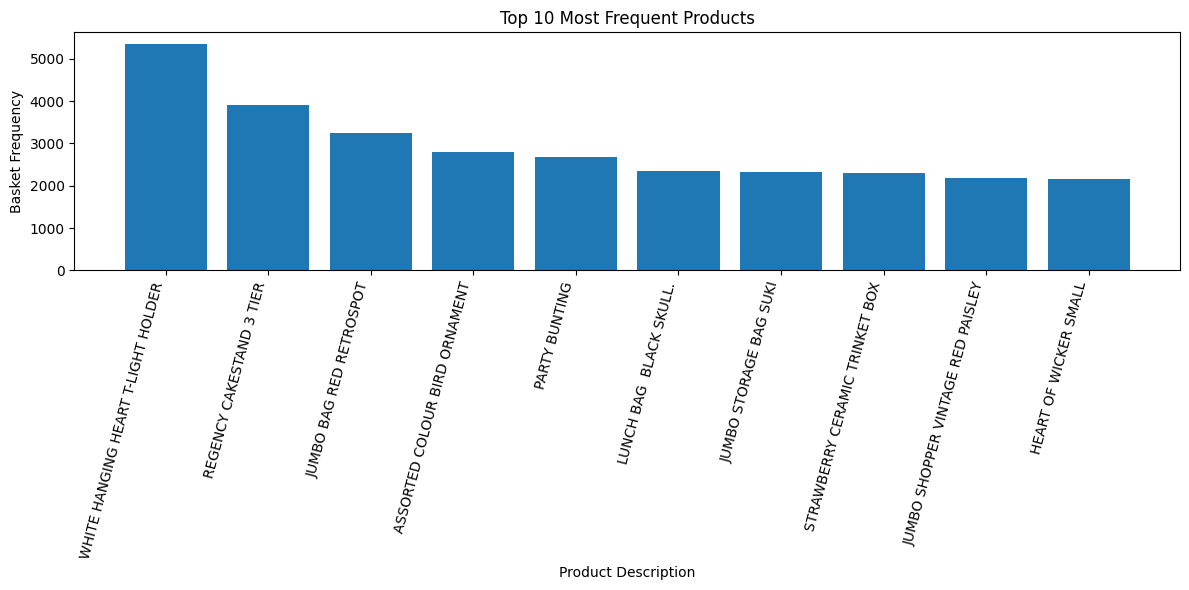

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    top_products["Description"],
    top_products["basket_frequency"]
)

plt.title("Top 10 Most Frequent Products")
plt.xlabel("Product Description")
plt.ylabel("Basket Frequency")

plt.xticks(rotation=75, ha="right")

plt.tight_layout()

plt.show()

## Step 5: Phân tích số lần mua cùng nhau giữa các sản phẩm

Bước này xác định các cặp sản phẩm thường xuất hiện cùng nhau trong một giỏ hàng.

Kết quả giúp phát hiện các mối quan hệ mua kèm phổ biến giữa các sản phẩm và cung cấp cơ sở cho các chiến lược cross-selling.

In [ ]:
query = """
SELECT
    a.Description AS product_A,
    b.Description AS product_B,
    COUNT(DISTINCT a.InvoiceNo) AS co_occurrence_count
FROM basket_items a
JOIN basket_items b
    ON a.InvoiceNo = b.InvoiceNo
   AND a.StockCode < b.StockCode
GROUP BY a.Description, b.Description
ORDER BY co_occurrence_count DESC
LIMIT 10;
"""

# Thực thi truy vấn SQL
top_pairs = pd.read_sql(query, conn)

# Hiển thị kết quả
top_pairs

,product_A,product_B,co_occurrence_count
0,RED HANGING HEART T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER,1240
1,WOODEN PICTURE FRAME WHITE FINISH,WOODEN FRAME ANTIQUE WHITE,1114
2,JUMBO STORAGE BAG SUKI,JUMBO BAG RED RETROSPOT,1096
3,SWEETHEART CERAMIC TRINKET BOX,STRAWBERRY CERAMIC TRINKET BOX,1052
4,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,1023
5,JUMBO SHOPPER VINTAGE RED PAISLEY,JUMBO BAG RED RETROSPOT,1008
6,HEART OF WICKER SMALL,HEART OF WICKER LARGE,1001
7,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,966
8,PACK OF 60 PINK PAISLEY CAKE CASES,60 TEATIME FAIRY CAKE CASES,926
9,JUMBO BAG RED RETROSPOT,JUMBO BAG STRAWBERRY,924


## Trực quan hóa các cặp sản phẩm mua cùng nhau nhiều nhất

Biểu đồ cột được sử dụng để hiển thị các cặp sản phẩm có số lần xuất hiện cùng nhau cao nhất trong tập dữ liệu.

Những cặp sản phẩm này là các ứng viên tiềm năng cho chiến lược bán kèm (cross-selling).

/tmp/ipykernel_690/2716406496.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


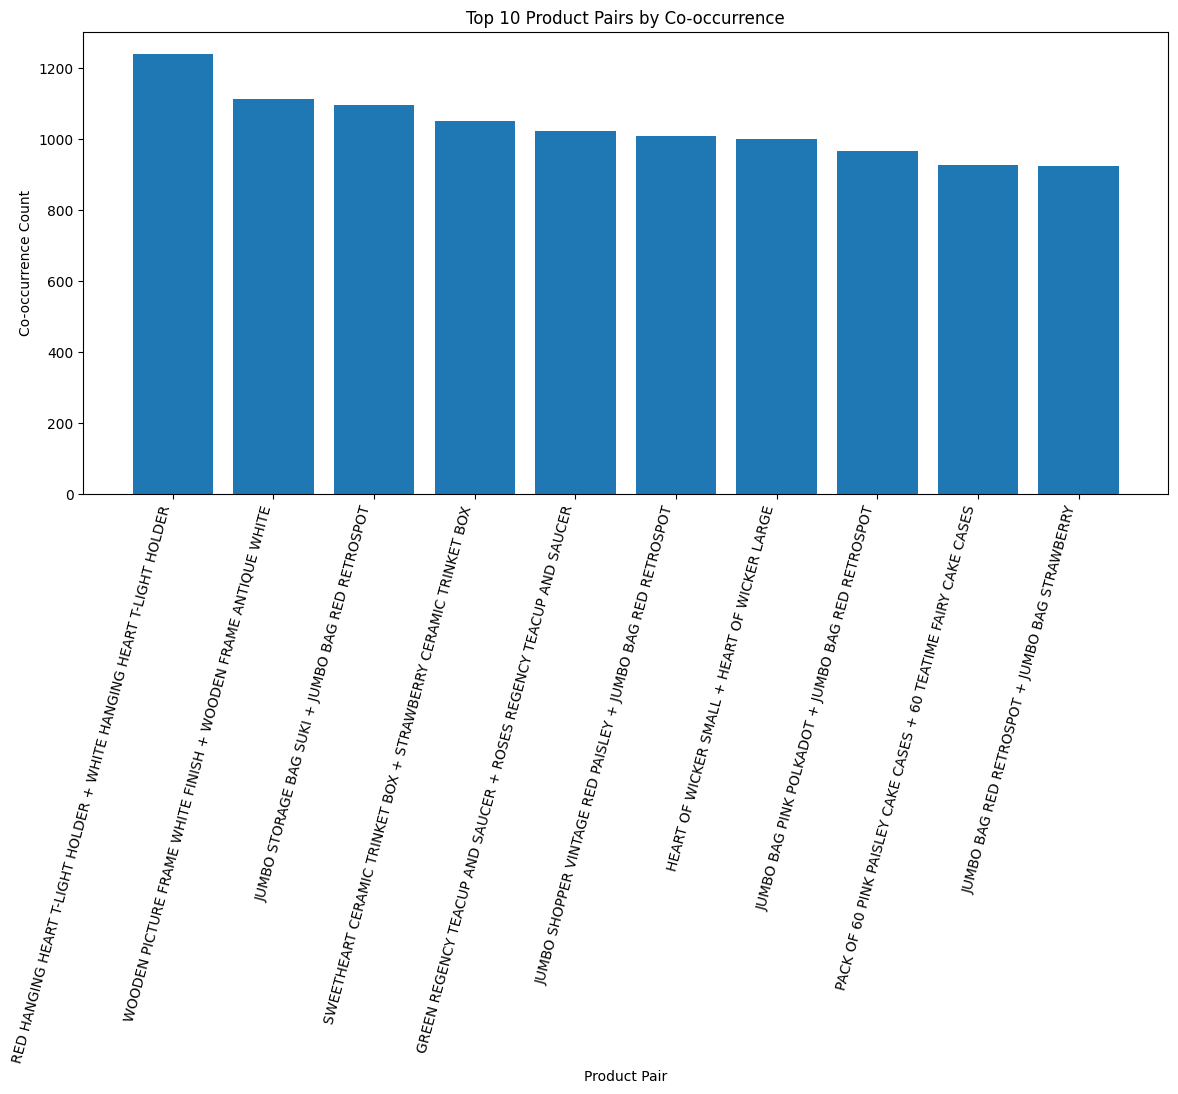

In [ ]:
import matplotlib.pyplot as plt

# Tạo tên cặp sản phẩm
top_pairs["product_pair"] = (
    top_pairs["product_A"] +
    " + " +
    top_pairs["product_B"]
)

plt.figure(figsize=(14,6))

plt.bar(
    top_pairs["product_pair"],
    top_pairs["co_occurrence_count"]
)

plt.title("Top 10 Product Pairs by Co-occurrence")
plt.xlabel("Product Pair")
plt.ylabel("Co-occurrence Count")

plt.xticks(rotation=75, ha="right")

plt.tight_layout()

plt.show()